# Parent Faults

This notebook demonstrates parent-fault-level view classes. Topics covered:

1. Creating a `ParentFault` facade
2. `ParentFaultData` — subsection attributes, surface trace, faulting style
3. `ParentFaultRuptures` — participating ruptures and cumulative MFDs
4. Direct instantiation of `ParentFaultData` and `ParentFaultRuptures`

In [1]:
import matplotlib.pyplot as plt

from parserf.models import FaultModel, FaultModelDataset
from parserf.parent import ParentFault, ParentFaultData, ParentFaultRuptures

In [2]:
ds = FaultModelDataset(FaultModel.NSHMP_2023)

## 1. ParentFault Facade

`ParentFault` validates the name and exposes `.data` and `.ruptures`.

In [3]:
flt = ParentFault(ds, name="Compton")
print(flt)

ParentFault(fault_model=NSHMP_2023, name='Compton', parent_id=43)


## 2. ParentFaultData

In [4]:
print("Name:       ", flt.data.name)
print("Parent ID:  ", flt.data.parent_id)
print("Fault Model:", flt.data.fault_model)

Name:        Compton
Parent ID:   43
Fault Model: 2023


### Child subsections

In [5]:
subs = flt.data.subsections
print(f"{len(subs)} subsections")
subs

5 subsections


,name,dip,dip_direction,upper_depth_km,lower_depth_km,aseismicity,length_km,width_km,area_km2,geometry
index,,,,,,,,,,
809,Compton (0),20.0,34.0,5.2,15.6,0.1,12.978331,30.407566,394.639455,"LINESTRING (-118.06065 33.68127, -118.13114 33..."
810,Compton (1),20.0,34.0,5.2,15.6,0.1,12.983062,30.407566,394.783297,"LINESTRING (-118.1787 33.74269, -118.22804 33...."
811,Compton (2),20.0,34.0,5.2,15.6,0.1,12.985653,30.407566,394.862090,"LINESTRING (-118.30314 33.79592, -118.31471 33..."
812,Compton (3),20.0,34.0,5.2,15.6,0.1,12.979565,30.407566,394.676979,"LINESTRING (-118.43104 33.84393, -118.43655 33..."
813,Compton (4),20.0,34.0,5.2,15.6,0.1,12.954084,30.407566,393.902164,"LINESTRING (-118.55061 33.90376, -118.5863 33...."


In [6]:
subs[["dip", "upper_depth_km", "lower_depth_km", "length_km", "width_km", "area_km2"]].describe()

,dip,upper_depth_km,lower_depth_km,length_km,width_km,area_km2
count,5.0,5.0,5.0,5.000000,5.000000,5.000000
mean,20.0,5.2,15.6,12.976139,30.407566,394.572797
std,0.0,0.0,0.0,0.012663,0.000000,0.385048
min,20.0,5.2,15.6,12.954084,30.407566,393.902164
25%,20.0,5.2,15.6,12.978331,30.407566,394.639455
50%,20.0,5.2,15.6,12.979565,30.407566,394.676979
75%,20.0,5.2,15.6,12.983062,30.407566,394.783297
max,20.0,5.2,15.6,12.985653,30.407566,394.862090


### Surface trace

Individual subsection traces vs. the merged and oriented surface trace.

In [7]:
print("Dip:          ", flt.data.dip, "\u00b0")
print("Dip direction:", flt.data.dip_direction, "\u00b0")

Dip:           20 °
Dip direction: 34 °


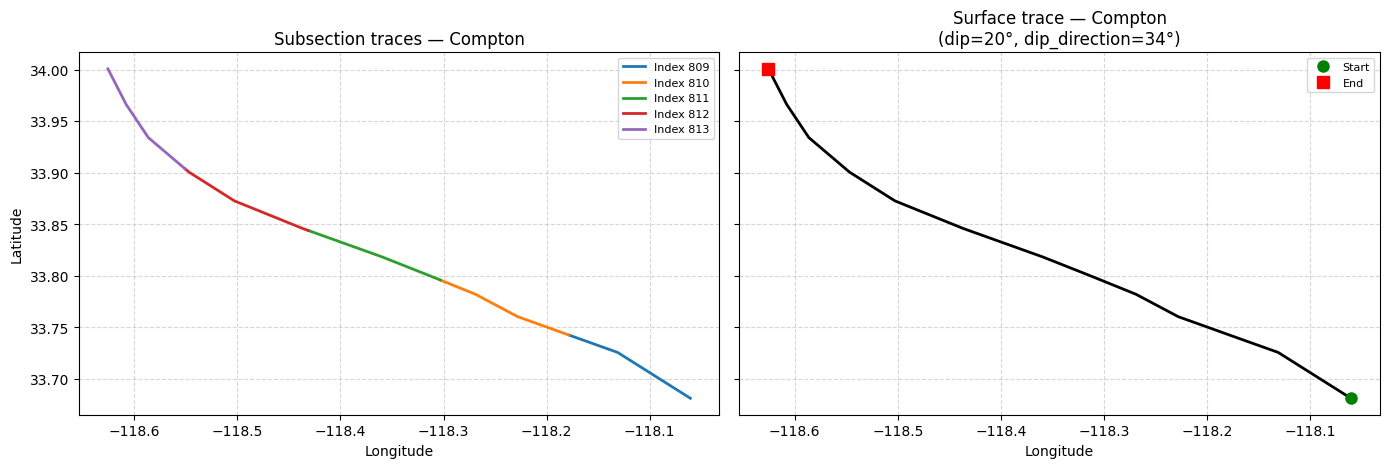

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Left: individual subsection traces
for idx, row in subs.iterrows():
    xs, ys = row["geometry"].xy
    ax1.plot(xs, ys, linewidth=2, label=f"Index {idx}")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_title(f"Subsection traces \u2014 {flt.data.name}")
ax1.legend(fontsize=8)
ax1.set_aspect("equal")
ax1.grid(True, linestyle="--", alpha=0.5)

# Right: merged and oriented surface trace
trace = flt.data.surface_trace
lons, lats = trace.xy
ax2.plot(lons, lats, linewidth=2, color="black")
ax2.plot(lons[0], lats[0], "o", color="green", markersize=8, label="Start")
ax2.plot(lons[-1], lats[-1], "s", color="red", markersize=8, label="End")
ax2.set_xlabel("Longitude")
ax2.set_title(
    f"Surface trace \u2014 {flt.data.name}\n"
    f"(dip={flt.data.dip}\u00b0, dip_direction={flt.data.dip_direction}\u00b0)"
)
ax2.legend(fontsize=8)
ax2.set_aspect("equal")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Faulting style

In [9]:
print("Dominant style:", flt.data.style)
flt.data.style_counts

Dominant style: reverse oblique


,style,count
0,reverse oblique,15806
1,reverse,11475
2,strike-slip,61


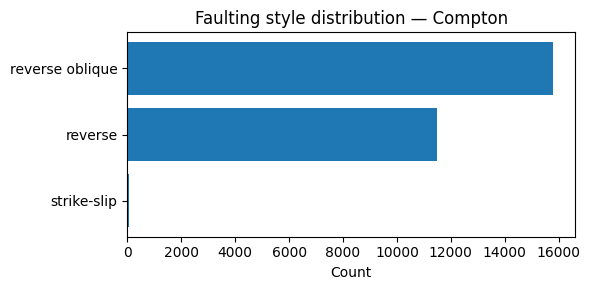

In [10]:
sc = flt.data.style_counts
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(sc["style"], sc["count"])
ax.set_xlabel("Count")
ax.set_title(f"Faulting style distribution \u2014 {flt.data.name}")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. ParentFaultRuptures

### participating_ruptures

GeoDataFrame of all ruptures involving any child subsection of this parent fault. Data is
in exploded form: one row per (rupture, parent) pair with `parent_id` and `area_pct`
columns.

In [11]:
rups = flt.ruptures.participating_ruptures
unique_count = rups.index.nunique()
print(f"{len(rups)} rows ({unique_count} unique ruptures)")
print("Columns:", list(rups.columns))
rups.head()

35417 rows (7365 unique ruptures)
Columns: ['m', 'rate', 'depth', 'dip', 'width', 'rake', 'geometry', 'length_km', 'area_km2', 'parent_id', 'area_pct']


,m,rate,depth,dip,width,rake,geometry,length_km,area_km2,parent_id,area_pct
1956,7.15,1.669645e-09,3.241,45.1,21.252,71.0,"MULTILINESTRING ((-118.552 34.0202, -118.64926...",49.174780,1088.344469,3,43.560923
1956,7.15,1.669645e-09,3.241,45.1,21.252,71.0,"MULTILINESTRING ((-118.552 34.0202, -118.64926...",49.174780,1088.344469,43,36.192784
1956,7.15,1.669645e-09,3.241,45.1,21.252,71.0,"MULTILINESTRING ((-118.552 34.0202, -118.64926...",49.174780,1088.344469,183,20.246293
1957,7.36,5.858259e-10,3.296,38.5,22.825,71.0,"MULTILINESTRING ((-118.552 34.0202, -118.64926...",71.108453,1711.583027,3,27.699088
1957,7.36,5.858259e-10,3.296,38.5,22.825,71.0,"MULTILINESTRING ((-118.552 34.0202, -118.64926...",71.108453,1711.583027,43,23.013909


### cumulative_mfds

Cumulative magnitude frequency distributions for each child subsection.

In [12]:
mfds = flt.ruptures.cumulative_mfds
print(f"Total rows: {len(mfds)}")
print(f"Subsection indices: {sorted(mfds['index'].unique())}")
mfds.head()

Total rows: 495
Subsection indices: [np.int64(809), np.int64(810), np.int64(811), np.int64(812), np.int64(813)]


,index,magnitude,cumulative_rate
0,809,6.98,0.000552
1,809,7.05,0.000499
2,809,7.07,0.000499
3,809,7.09,0.000499
4,809,7.11,0.000469


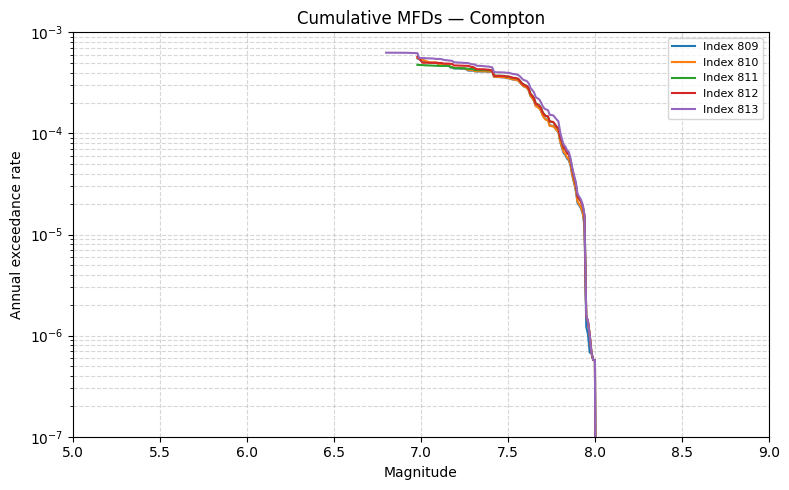

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
for idx, group in mfds.groupby("index"):
    ax.semilogy(group["magnitude"], group["cumulative_rate"], linewidth=1.5, label=f"Index {idx}")
ax.set_xlabel("Magnitude")
ax.set_ylabel("Annual exceedance rate")
ax.set_title(f"Cumulative MFDs \u2014 {flt.data.name}")
ax.set(xlim=(5, 9), ylim=(1e-7, 1e-3))
ax.legend(fontsize=8)
ax.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Direct Instantiation

`ParentFaultData` and `ParentFaultRuptures` can be used standalone. They take
`parent_id` (an integer) rather than `name`.

In [14]:
pid = ds.get_parent_fault_id(name="Compton")

data = ParentFaultData(ds, parent_id=pid)
print("Name:", data.name)
print("Subsections:", len(data.subsections))

Name: Compton
Subsections: 5


In [15]:
ruptures = ParentFaultRuptures(ds, parent_id=pid)
print("Cumulative MFD rows:", len(ruptures.cumulative_mfds))

Cumulative MFD rows: 495
